In [5]:
# ============================================================
# Logistic Noise-Contrastive Estimation / Density-Ratio Learning
# One-class probabilistic modeling (low-N, high-d friendly)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# 1. Generate synthetic noise
# -----------------------------
def generate_noise(X_pos, noise_multiplier=3, inflation=1.5):
    """
    X_pos: numpy array (N, d) of positive-only samples
    """
    mu = X_pos.mean(axis=0)
    cov = np.cov(X_pos.T)

    cov_noise = inflation * cov + 1e-4 * np.eye(cov.shape[0])

    X_neg = np.random.multivariate_normal(
        mean=mu,
        cov=cov_noise,
        size=noise_multiplier * len(X_pos)
    )
    return X_neg


# -----------------------------
# 2. Build NCE dataset
# -----------------------------
def build_dataset(X_pos):
    X_neg = generate_noise(X_pos)

    X_all = np.vstack([X_pos, X_neg])
    y = np.hstack([
        np.ones(len(X_pos)),   # real data
        np.zeros(len(X_neg))   # noise
    ])

    return (
        torch.tensor(X_all, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        len(X_pos)
    )


# -----------------------------
# 3. Density-ratio model
# -----------------------------
class DensityRatioModel(nn.Module):
    """
    f(x) ≈ log p(x | class) - log q(x)
    """
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)  # logits


# -----------------------------
# 4. Train with logistic NCE
# -----------------------------
def train_density_ratio_model(X, y, epochs=300, lr=1e-3, weight_decay=1e-3):
    model = DensityRatioModel(X.shape[1])

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.BCEWithLogitsLoss()

    for _ in range(epochs):
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

    return model


# -----------------------------
# 5. Diagnostics
# -----------------------------
def sanity_checks(model, X, y, n_pos):
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        acc = (preds == y).float().mean()

        pos_scores = logits[:n_pos]
        neg_scores = logits[n_pos:]

    print(f"Training accuracy: {acc.item():.3f}")
    print(f"Mean log-ratio (real):  {pos_scores.mean().item():.3f}")
    print(f"Mean log-ratio (noise): {neg_scores.mean().item():.3f}")


# -----------------------------
# 6. Score new samples
# -----------------------------
def score_samples(model, X_new):
    """
    Returns log density ratio scores.
    Higher = more likely from the learned class.
    """
    with torch.no_grad():
        return model(X_new)


# ============================================================
# Example usage
# ============================================================
if __name__ == "__main__":
    # Synthetic positive-only data
    np.random.seed(0)
    X_pos = np.random.randn(40, 5)  # low N, moderate d

    # Build dataset
    X, y, n_pos = build_dataset(X_pos)

    # Train
    model = train_density_ratio_model(X, y)

    # Diagnostics
    sanity_checks(model, X, y, n_pos)

    # Score new points
    X_test = torch.randn(5, 5)
    scores = score_samples(model, X_test)

    print("\nTest log density ratios:")
    print(scores.numpy())


Training accuracy: 0.675
Mean log-ratio (real):  -0.247
Mean log-ratio (noise): -0.397

Test log density ratios:
[-0.5345065   0.23143357 -1.2118218  -0.13895176 -0.45198914]


epoch: 0
epoch: 1
epoch: 2
epoch: 3
epoch: 4
epoch: 5
epoch: 6
epoch: 7
epoch: 8
epoch: 9
epoch: 10
epoch: 11
epoch: 12
epoch: 13
epoch: 14
epoch: 15
epoch: 16
epoch: 17
epoch: 18
epoch: 19
epoch: 20
epoch: 21
epoch: 22
epoch: 23
epoch: 24
epoch: 25
epoch: 26
epoch: 27
epoch: 28
epoch: 29
epoch: 30
epoch: 31
epoch: 32
epoch: 33
epoch: 34
epoch: 35
epoch: 36
epoch: 37
epoch: 38
epoch: 39
epoch: 40
epoch: 41
epoch: 42
epoch: 43
epoch: 44
epoch: 45
epoch: 46
epoch: 47
epoch: 48
epoch: 49
epoch: 50
epoch: 51
epoch: 52
epoch: 53
epoch: 54
epoch: 55
epoch: 56
epoch: 57
epoch: 58
epoch: 59
epoch: 60
epoch: 61
epoch: 62
epoch: 63
epoch: 64
epoch: 65
epoch: 66
epoch: 67
epoch: 68
epoch: 69
epoch: 70
epoch: 71
epoch: 72
epoch: 73
epoch: 74
epoch: 75
epoch: 76
epoch: 77
epoch: 78
epoch: 79
epoch: 80
epoch: 81
epoch: 82
epoch: 83
epoch: 84
epoch: 85
epoch: 86
epoch: 87
epoch: 88
epoch: 89
epoch: 90
epoch: 91
epoch: 92
epoch: 93
epoch: 94
epoch: 95
epoch: 96
epoch: 97
epoch: 98
epoch: 99
Accuracy: 

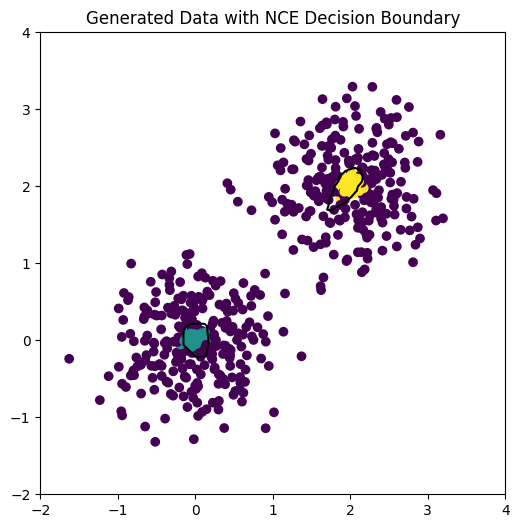

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -- Data Generation -- 
def generate_data(num_samples, noise_std=0.05):
    np.random.seed(123)
    centers = [(0, 0), (2, 2)]  # Centers of the two data clusters
    data, labels = [], []
    for i in range(int(num_samples/2)):
        center_idx = np.random.randint(0, 2)  # Randomly select a cluster center
        center = centers[center_idx]

        minor_noise = noise_std * np.random.randn(2)
        major_noise = 10 * noise_std * np.random.randn(2)
        #print(f'center: {center}, minor_noise: {minor_noise}, major_noise: {major_noise}')

        x, y = center + minor_noise
        data.append([x, y])
        labels.append(center_idx)

        noise_x, noise_y = center + major_noise
        data.append([noise_x, noise_y])
        labels.append(-1) # -1 means noise
    return torch.tensor(data, dtype=torch.float32), torch.tensor(labels)


# --  Discriminative Model --
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 32)  # Input layer to hidden layer
        self.fc2 = nn.Linear(32, 32)  # Input layer to hidden layer
        self.fc3 = nn.Linear(32, 1)  # Hidden layer to output layer
        self.sigmoid = nn.Sigmoid()  # Sigmoid for binary classification output

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Apply ReLU activation
        x = torch.relu(self.fc2(x))  # Apply ReLU activation
        x = self.fc3(x)
        return self.sigmoid(x)  # Output between 0 and 1 for probability-like score


# -- Generate data -- 
num_samples = 1000
num_train = 800
num_test = num_samples - num_train
data, labels = generate_data(num_samples)
train_data, train_labels = data[:num_train], labels[:num_train]
test_data, test_labels = data[num_train:], labels[num_train:]

# -- Training --
model = Discriminator()
loss_fn = nn.BCEWithLogitsLoss()  # Built-in loss combines sigmoid and BCE for efficiency
optimizer = optim.Adam(model.parameters())

for epoch in range(100):
    print('epoch:', epoch)
    for x, label in zip(train_data, train_labels):
        output = model(x)
        if label == -1: # noise
            loss = loss_fn(output, torch.zeros_like(output))
        else: # real
            loss = loss_fn(output, torch.ones_like(output))
        #print(f'epoch: {epoch}, x: {x}, label: {label}, output: {output}, loss: {loss}')
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()  # Update model parameters

# -- Evaluation --
correct = 0
total = 0
with torch.no_grad():
    for x, label in zip(test_data, test_labels):
        output = model(x)
        predicted = (output > 0.5).item()  # Predict label based on output score
        #print(f'x: {x}, label: {label}, output: {output}, predicted: {predicted}')
        total += 1
        if label == -1:
          if predicted == False:
            correct += 1
        else:
          if predicted == True:
            correct += 1

print(f"Accuracy: {correct / total * 100:.2f}%")

# -- Visualization --
plt.figure(figsize=(6, 6))
plt.scatter(data[:,0], data[:,1], c=labels)
plt.title("Generated Data with NCE Decision Boundary")

# Approximate decision boundary (could be improved)
x_vals = np.linspace(-2, 4, 100)
y_vals = np.linspace(-2, 4, 100)
xv, yv = np.meshgrid(x_vals, y_vals)
grid_input = torch.tensor(np.stack([xv.ravel(), yv.ravel()], axis=1), dtype=torch.float32)
grid_output = model(grid_input).view(xv.shape).detach().numpy()
plt.contour(xv, yv, grid_output, levels=[0.5], colors='k')

plt.show()

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import polars as pl
from pathlib import Path
import airportsdata as ad

class DataProcessing:
    def __init__(self):
        self.cwd = Path.cwd().parent
        self.excel_path = Path(self.cwd, "data/Airlink - UMichiagn - Data Collection - 9.8.2025.xlsx")
        self.mapping = {}
        self.airports = ad.load('IATA')


    def geolocate_airports(self, df: pl.DataFrame):
        def get_lat_lon(code):
            airport = self.airports.get(code)
            if airport is None:
                return {"lat": None, "lon": None}
            return {"lat": airport["lat"], "lon": airport["lon"]}

        geo_dtype = pl.Struct([
            pl.Field("lat", pl.Float64),
            pl.Field("lon", pl.Float64),
        ])

        ret = df.with_columns([
            pl.col("Origin")
            .map_elements(get_lat_lon, return_dtype=geo_dtype)
            .struct.field("lat")
            .alias("Origin_Lat"),

            pl.col("Origin")
            .map_elements(get_lat_lon, return_dtype=geo_dtype)
            .struct.field("lon")
            .alias("Origin_Lon"),

            pl.col("Destination")
            .map_elements(get_lat_lon, return_dtype=geo_dtype)
            .struct.field("lat")
            .alias("Destination_Lat"),

            pl.col("Destination")
            .map_elements(get_lat_lon, return_dtype=geo_dtype)
            .struct.field("lon")
            .alias("Destination_Lon"),
        ])
        
        return ret
  

    def load_shipping_data(self, filepath: Path):
        # Read Raw (as strings) to handle mixed headers
        df_raw = pl.read_excel(filepath, has_header=False, infer_schema_length=0)

        # Extract Year & Clean
        df_clean = (
            df_raw
            .with_columns(
                pl.col("column_1")
                .str.extract(r"^(\d{4})", 1)
                .forward_fill()
                .alias("Year")
            )
            .filter(
                ~pl.col("column_1").str.contains(r"^\d{4}.*Completed Shipments"),
                pl.col("column_1") != "NGO ID",
                pl.col("column_1") != "Mirror",
                pl.col("column_2").is_not_null(),
                pl.col("column_2").str.strip_chars() != ""
            )
        )

        # Rename Columns (Mapping from row 1 of raw file)
        header_row = df_raw.row(1)
        rename_map = {f"column_{i+1}": name for i, name in enumerate(header_row) if name}
        
        df_final = (
            df_clean
            .rename(rename_map)
            .with_columns([
                pl.col("Year").cast(pl.Int32)
                # pl.lit(1.0).alias("s_label") # These are all Positives
            ])
        )
        return df_final


    def preprocess_to_tensor(self, df: pl.DataFrame):
        # NOTE these feature columns may need to be adjusted based on data available
        feature_cols = [
            "Origin",
            "AW (kg)",
            "Pallets"
        ]

        # check if the values in the column can be directly converted to numbers if not build a map and encode
        for col in feature_cols:
            try: 
                # NOTE : fill Nones are creating issues changing to zero for now, need to fully decide how these are handled going forward
                df = df.with_columns(pl.col(col).replace("", None).cast(pl.Float32).fill_null(0.0))
            except:          
                uniq_vals = df[col].unique().to_list()
                self.mapping[col] = {val: idx for idx, val in enumerate(uniq_vals)}
                df = df.with_columns(
                    pl.Series(col, [self.mapping[col][val] for val in df[col]], dtype=pl.Int32)
                )

        data_np = df.select(feature_cols).to_numpy().astype(np.float32)

        # Normalize data for ease of training
        data_tensor = torch.tensor(data_np)
        mean = data_tensor.mean(dim=0)
        std = data_tensor.std(dim=0) + 1e-6
        data_tensor = (data_tensor - mean) / (std + 1e-6)

        return data_tensor
    
    def transform_new_data(self, df: pl.DataFrame):
        # TODO : verify correctness and ability to handle unseen categories if not conditions managed above in preprocessing
        feature_cols = [
            "Origin",
            'Dest',
            "AW (kg)",
            "Pallets",
            'Origin_Lat',
            'Origin_Lon',
            'Destination_Lat',
            'Destination_Lon'
        ]

        for col, map in self.mapping.items():
            if col in self.mapping:
                df = df.with_columns(
                    pl.Series(col, [self.mapping[col].get(val, -1) for val in df[col]], dtype=pl.Int32)
                )
            else:
                df = df.with_columns(pl.col(col).cast(pl.Float32))

        data_np = df.select(feature_cols).to_numpy().astype(np.float32)
        return torch.tensor(data_np)

In [87]:
data_handler = DataProcessing()
df = data_handler.load_shipping_data(data_handler.excel_path)
df_geo = data_handler.geolocate_airports(df)
# display(df_geo.head())
data_tensor = data_handler.preprocess_to_tensor(df_geo)
display(data_tensor[:5])


tensor([[-1.0632, -0.3457, -0.2787],
        [ 0.3802, -0.3455, -0.3014],
        [ 0.9473, -0.3201, -0.3240],
        [ 0.3802, -0.2693, -0.2787],
        [ 0.6380, -0.3546, -0.3467]])

In [38]:
df_shipping.select(['Pallets'])
# disp all rows
pl.Config.set_tbl_rows(100)

polars.config.Config

In [3]:
class NoiseGeneration:
    def __init__(self, data, inflation=1.5):
        mu = torch.mean(data, dim=0)
        cov = torch.from_numpy(np.cov(data.numpy(), rowvar=False)).float()

        # read about how to do this
        cov_numpy = np.cov(data.numpy(), rowvar=False)
        cov = torch.from_numpy(cov_numpy).float()

        epsilon = 1e-5 * torch.eye(cov.shape[0])
        cov_noise = (inflation ** 2) * (cov + epsilon)

        self.dist = torch.distributions.MultivariateNormal(mu, cov_noise)

    def sample(self, n):
        return self.dist.sample((n,))
    
    def log_prob(self, x):
        return self.dist.log_prob(x)


class NCE(nn.Module):
    def __init__(self, model, noise_gen, noise_multiplier=3):
        super().__init__()
        self.model = model
        self.noise_gen = noise_gen
        self.noise_multiplier = noise_multiplier
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, x):
        batch_size = x.shape[0]
        
        noise_x = self.noise_gen.sample(batch_size * self.noise_multiplier)

        score_obs = self.model(x).squeeze()
        score_noise = self.model(noise_x).squeeze()

        log_q_obs = self.noise_gen.log_prob(x).detach()
        log_q_noise = self.noise_gen.log_prob(noise_x).detach()

        logits_obs = score_obs - log_q_obs
        logits_noise = score_noise - log_q_noise

        loss_obs = self.bce(logits_obs, torch.ones_like(logits_obs))
        loss_noise = self.bce(logits_noise, torch.zeros_like(logits_noise))

        loss = loss_obs + loss_noise
        return loss
    

Epoch 1/200, Loss: 7.0259
Epoch 2/200, Loss: 5.2581
Epoch 3/200, Loss: 2.8535
Epoch 4/200, Loss: 1.2183
Epoch 5/200, Loss: 0.7081
Epoch 6/200, Loss: 0.6076
Epoch 7/200, Loss: 0.5688
Epoch 8/200, Loss: 0.5775
Epoch 9/200, Loss: 0.5440
Epoch 10/200, Loss: 0.5312
Epoch 11/200, Loss: 0.5351
Epoch 12/200, Loss: 0.5361
Epoch 13/200, Loss: 0.5291
Epoch 14/200, Loss: 0.5197
Epoch 15/200, Loss: 0.5217
Epoch 16/200, Loss: 0.4569
Epoch 17/200, Loss: 0.5006
Epoch 18/200, Loss: 0.4676
Epoch 19/200, Loss: 0.4634
Epoch 20/200, Loss: 0.4307
Epoch 21/200, Loss: 0.4263
Epoch 22/200, Loss: 0.4382
Epoch 23/200, Loss: 0.4165
Epoch 24/200, Loss: 0.4362
Epoch 25/200, Loss: 0.4164
Epoch 26/200, Loss: 0.3960
Epoch 27/200, Loss: 0.4251
Epoch 28/200, Loss: 0.3969
Epoch 29/200, Loss: 0.4065
Epoch 30/200, Loss: 0.3679
Epoch 31/200, Loss: 0.3764
Epoch 32/200, Loss: 0.3726
Epoch 33/200, Loss: 0.3647
Epoch 34/200, Loss: 0.3504
Epoch 35/200, Loss: 0.3577
Epoch 36/200, Loss: 0.3350
Epoch 37/200, Loss: 0.3573
Epoch 38/2

Text(0.5, 1.0, 'NCE Training Loss over Epochs')

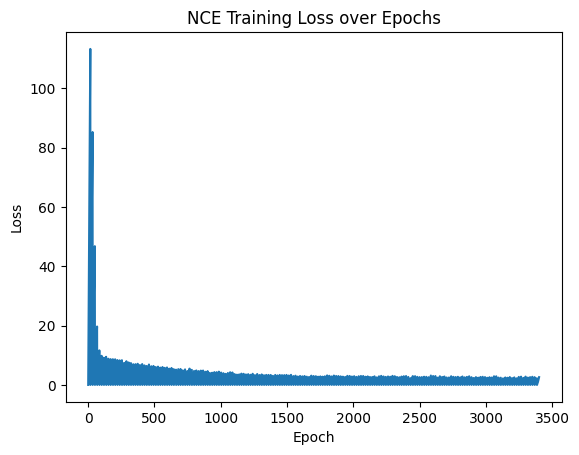

In [11]:
data_handler = DataProcessing()
df_shipping = data_handler.load_shipping_data(data_handler.excel_path)
complete_tensor_shipping = data_handler.preprocess_to_tensor(df_shipping)
# random seed
torch.manual_seed(42)
# sample 70% of rows for training based on the seed
k = int(len(complete_tensor_shipping) * 0.7)
indices = torch.randperm(len(complete_tensor_shipping))[:k]
tensor_shipping = complete_tensor_shipping[indices]

test_set = complete_tensor_shipping[~torch.isin(torch.arange(len(complete_tensor_shipping)), indices)]
# print(df_shipping.select(["Origin", "AW (kg)", "Pallets"]).head(10))
# print(tensor_shipping[:10])

input_dim = tensor_shipping.shape[1]

noise_gen = NoiseGeneration(tensor_shipping, inflation=3.0)
# TODO : tune this
model = nn.Sequential(
    # need to tune neuron counts and layers
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    # nn.Linear(input_dim, 32),
    # nn.ReLU(),
    # nn.Linear(32, 1),
    # nn.Sigmoid()
)

nce_model = NCE(model, noise_gen, noise_multiplier=3)
optimizer = optim.Adam(nce_model.parameters(), lr=1e-3, weight_decay=1e-3)

num_epochs = 200
dataset = torch.utils.data.TensorDataset(tensor_shipping)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=25, shuffle=True)

loss_per_epoch = []

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in dataloader:
        loss_per_epoch.append(total_loss)
        obs_batch = batch[0]
        
        optimizer.zero_grad()
        loss = nce_model(obs_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(dataloader):.4f}")
    # NOTE plot against test set

# plot loss over epochs
import matplotlib.pyplot as plt
plt.figure()
plt.plot(range(1, len(loss_per_epoch)+1), loss_per_epoch)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('NCE Training Loss over Epochs')

Real Data Avg Score: 0.1800
Mutant Data Avg Score: 0.1878
Noise Data Avg Score:  0.0128


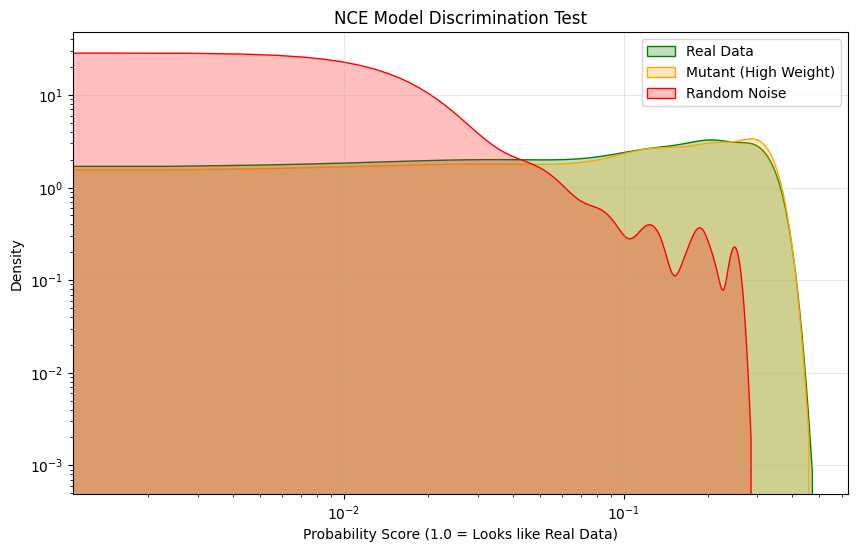

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

def test_model_performance(model, real_data_tensor):
    model.eval() # Set to evaluation mode
    
    # ==========================================
    # 1. SCORE THE REAL DATA
    # ==========================================
    with torch.no_grad():
        # Get raw logits (energy scores)
        real_scores = model(real_data_tensor).squeeze()
        # Convert to probability (0 to 1) just for readability
        real_probs = torch.sigmoid(real_scores).numpy()

    print(f"Real Data Avg Score: {real_probs.mean():.4f}")

    # # ==========================================
    # # 2. CREATE "MUTANT" ANOMALIES
    # # ==========================================
    # # We take the real data and corrupt it to see if the model notices.
    
    # # Clone the data so we don't mess up the original
    # mutant_tensor = real_data_tensor.clone()
    
    # # A. The "Heavy Payload" Anomaly: 
    # # Assume column 1 is "Weight" (or whichever numeric col you have). 
    # # We add 5 standard deviations to it.
    # mutant_tensor[:, 1] = mutant_tensor[:, 1] + 5.0 
    
    # just use tenst tensor test_set
    mutant_tensor = test_set.clone()
    
    # B. The "Random Noise" Anomaly:
    # Completely random noise (what the model trained against)
    noise_tensor = torch.randn_like(real_data_tensor)

    # ==========================================
    # 3. SCORE THE ANOMALIES
    # ==========================================
    with torch.no_grad():
        mutant_scores = model(mutant_tensor).squeeze()
        mutant_probs = torch.sigmoid(mutant_scores).numpy()
        
        noise_scores = model(noise_tensor).squeeze()
        noise_probs = torch.sigmoid(noise_scores).numpy()

    print(f"Mutant Data Avg Score: {mutant_probs.mean():.4f}")
    print(f"Noise Data Avg Score:  {noise_probs.mean():.4f}")

    # ==========================================
    # 4. VISUALIZATION (The Truth Teller)
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    # Plot Real Data Scores (Should be right/high)
    sns.kdeplot(real_probs, fill=True, color='green', label='Real Data', clip=(0,1))
    
    # Plot Mutant Scores (Should be left/low)
    sns.kdeplot(mutant_probs, fill=True, color='orange', label='Mutant (High Weight)', clip=(0,1))
    
    # Plot Noise Scores (Should be far left/low)
    sns.kdeplot(noise_probs, fill=True, color='red', label='Random Noise', clip=(0,1))

    plt.title("NCE Model Discrimination Test")
    plt.xlabel("Probability Score (1.0 = Looks like Real Data)")
    plt.ylabel("Density")
    # make y axis log scale
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the test
test_model_performance(nce_model.model, tensor_shipping)

indices_test: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176]
mutant_probs: [2.00455904e-01 3.36476833e-01 3.70465398e-01 4.05374199e-01
 4.40631479e-01 3.87454540e-01 2.30187729e-01 2.54936188e-01
 2.25763217e-01 5.78802973e-02 2.35115588e-01 2.08695248e-01
 2.56852984e-01 3.65515292e-01 3.81561011e-01 3.51494908e-01
 2.962640

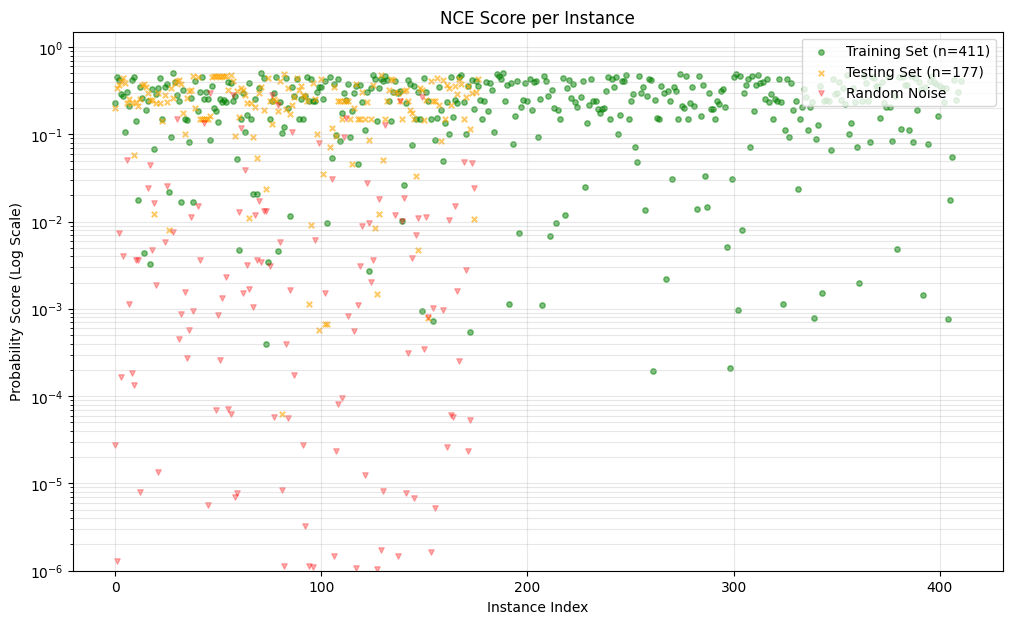

In [12]:
import matplotlib.pyplot as plt

def test_model_performance_scatter(model, real_data_tensor, test_data_tensor):
    model.eval()
    
    # ==========================================
    # 1. GENERATE SCORES
    # ==========================================
    with torch.no_grad():
        # A. Score Real Data (Training Set)
        real_scores = model(real_data_tensor).squeeze()
        real_probs = torch.sigmoid(real_scores).numpy()
        
        # B. Score Mutant Data (Test Set modified)
        mutant_tensor = test_data_tensor.clone()
        # Assuming column 1 is the weight/numeric column to distort
        # Make sure this column index exists in your tensor!
        # mutant_tensor[:, 1] = mutant_tensor[:, 1] + 5.0 
        
        mutant_scores = model(mutant_tensor).squeeze()
        mutant_probs = torch.sigmoid(mutant_scores).numpy()
        
        # C. Score Random Noise (Matching Test Set size for fair comparison)
        noise_tensor = torch.randn_like(test_data_tensor)
        noise_scores = model(noise_tensor).squeeze()
        noise_probs = torch.sigmoid(noise_scores).numpy()

    # ==========================================
    # 2. SCATTER PLOT
    # ==========================================
    plt.figure(figsize=(12, 7))
    
    # Create separate indices for each dataset since they might have different lengths
    indices_real = np.arange(len(real_probs))
    indices_test = np.arange(len(mutant_probs)) 
    print('indices_test:', indices_test)
    print('mutant_probs:', mutant_probs)
    # print top 10 mutant_probs highest values
    print('Top 10 mutant_probs:', np.sort(mutant_probs)[-10:])
    print('Top 10 true probs:', np.sort(real_probs)[-10:])
    print('Mutant mean prob:', np.mean(mutant_probs))
    print('Real mean prob:', np.mean(real_probs))
    
    # Plot Real Data (Green)
    plt.scatter(indices_real, real_probs, 
                c='green', alpha=0.5, s=15, label=f'Training Set (n={len(real_probs)})')

    # Plot Mutant Data (Orange)
    # We plot this against indices_test
    plt.scatter(indices_test, mutant_probs, 
                c='orange', alpha=0.6, s=15, marker='x', label=f'Testing Set (n={len(mutant_probs)})')

    # Plot Noise (Red)
    plt.scatter(indices_test, noise_probs, 
                c='red', alpha=0.3, s=15, marker='v', label='Random Noise')

    # Add a Threshold Line
    # plt.axhline(y=0.1, color='black', linestyle='--', linewidth=1, label='Possible Cutoff at (0.1)')

    plt.title("NCE Score per Instance")
    plt.xlabel("Instance Index")
    plt.ylabel("Probability Score (Log Scale)")
    
    # Log Scale Settings
    plt.yscale('log')
    # Valid range for probabilities is (0, 1]. 
    # We set bottom to 1e-5 to avoid log(0) errors and show low-scoring anomalies clearly.
    plt.ylim(1e-6, 1.5) 
    
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3, which="both") # 'both' shows grid for log ticks too
    
    plt.show()

# Run the test
# Pass BOTH your training set (for green dots) and test set (for orange dots)
test_model_performance_scatter(nce_model.model, tensor_shipping, test_set)

In [12]:
bb = ['DTW', 'BOS', 'DTW']
# cast bb as float32 tensor
# bb_tensor = torch.tensor(float(bb), dtype=torch.float32)

from sklearn import preprocessing
le = preprocessing.LabelEncoder()

aa = le.fit_transform(bb)
aa

aat = torch.as_tensor(aa, dtype=torch.float32)
aat

tensor([1., 0., 1.])

In [16]:
bb = ['DTW', 'BOS', 'DTW']

# map each unique string to an integer
vocab = {s: i for i, s in enumerate(set(bb))}
tensor = torch.tensor([vocab[s] for s in bb])

print(vocab)   # e.g. {'DTW': 0, 'BOS': 1}
print(tensor)  # tensor([0, 1, 0])

{'DTW': 0, 'BOS': 1}
tensor([0, 1, 0])


In [17]:
import polars as pl

# Sample airport dataset
df = pl.DataFrame({
    "origin_airport": ["JFK", "LAX", "ATL", "JFK", "LAX"],
    "destination_airport": ["SFO", "ORD", "DFW", "SFO", "ATL"],
    "distance": [2586, 1744, 731, 2586, 1946]
})

feature_cols = ["origin_airport", "destination_airport", "distance"]

print("Before encoding:")
print(df)
print(df.dtypes)

# Encode non-numeric columns
for col in feature_cols:
    if not df[col].dtype.is_numeric():
        df = df.with_columns(
            pl.col(col)
            .cast(pl.Categorical)
            .to_physical()
            .alias(col)
        )

print("\nAfter encoding:")
print(df)
print(df.dtypes)


Before encoding:
shape: (5, 3)
┌────────────────┬─────────────────────┬──────────┐
│ origin_airport ┆ destination_airport ┆ distance │
│ ---            ┆ ---                 ┆ ---      │
│ str            ┆ str                 ┆ i64      │
╞════════════════╪═════════════════════╪══════════╡
│ JFK            ┆ SFO                 ┆ 2586     │
│ LAX            ┆ ORD                 ┆ 1744     │
│ ATL            ┆ DFW                 ┆ 731      │
│ JFK            ┆ SFO                 ┆ 2586     │
│ LAX            ┆ ATL                 ┆ 1946     │
└────────────────┴─────────────────────┴──────────┘
[String, String, Int64]

After encoding:
shape: (5, 3)
┌────────────────┬─────────────────────┬──────────┐
│ origin_airport ┆ destination_airport ┆ distance │
│ ---            ┆ ---                 ┆ ---      │
│ u32            ┆ u32                 ┆ i64      │
╞════════════════╪═════════════════════╪══════════╡
│ 0              ┆ 0                   ┆ 2586     │
│ 1              ┆ 1          

In [18]:
import polars as pl
import torch

# Training data
df_train = pl.DataFrame({
    "origin_airport": ["JFK", "LAX", "ATL", "JFK", "LAX"],
    "destination_airport": ["SFO", "ORD", "DFW", "SFO", "ATL"],
    "distance": [2586, 1744, 731, 2586, 1946]
})

feature_cols = ["origin_airport", "destination_airport", "distance"]

# Build mapping for each categorical column
mappings = {}
for col in feature_cols:
    if not df_train[col].dtype.is_numeric():
        uniq_vals = df_train[col].unique().to_list()
        mappings[col] = {v: i for i, v in enumerate(uniq_vals)}
        df_train = df_train.with_columns(
            pl.Series(col, [mappings[col][v] for v in df_train[col]])
        )

# Convert to tensor
X_train = torch.tensor(df_train.to_numpy(), dtype=torch.float32)
print("Train tensor:")
print(X_train)

# Example: new data (with new airport)
df_test = pl.DataFrame({
    "origin_airport": ["JFK", "LAX", "BOS"],  # BOS is new
    "destination_airport": ["SFO", "ORD", "ATL"],
    "distance": [2586, 1744, 1200]
})

# Encode using the same mapping; unseen → -1
for col in feature_cols:
    if col in mappings:
        df_test = df_test.with_columns(
            pl.Series(col, [mappings[col].get(v, -1) for v in df_test[col]])
        )

X_test = torch.tensor(df_test.to_numpy(), dtype=torch.float32)
print("Test tensor:")
print(X_test)


Train tensor:
tensor([[1.0000e+00, 1.0000e+00, 2.5860e+03],
        [0.0000e+00, 0.0000e+00, 1.7440e+03],
        [2.0000e+00, 2.0000e+00, 7.3100e+02],
        [1.0000e+00, 1.0000e+00, 2.5860e+03],
        [0.0000e+00, 3.0000e+00, 1.9460e+03]])
Test tensor:
tensor([[ 1.0000e+00,  1.0000e+00,  2.5860e+03],
        [ 0.0000e+00,  0.0000e+00,  1.7440e+03],
        [-1.0000e+00,  3.0000e+00,  1.2000e+03]])
